In [8]:
# %% [markdown]
# # Analysis Notebook
# 核心计算库：chrom_core.py

# %%
%load_ext autoreload
%autoreload 2
import os
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import chrom_core as cc
import tomllib
# ==============================================================================
# 1. 项目配置与元数据管理 (PROJECT CONFIG)
# ==============================================================================

WORK_DIR = "../sim_out"
OUTPUT_DIR = "Figures_Final"
HIC_FILE = "../data/hic_data.dat"

os.makedirs(OUTPUT_DIR, exist_ok=True)
cc.set_pub_style()

# --- A. 自动发现所有组（即 WORK_DIR 下的所有子目录）---
all_items = os.listdir(WORK_DIR)
groups_to_process = sorted([
    item for item in all_items
    if os.path.isdir(os.path.join(WORK_DIR, item))
    and not item.startswith('.')  # 排除隐藏文件/目录
])

if not groups_to_process:
    raise ValueError(f"No valid simulation groups found in {WORK_DIR}")

print(f"Found {len(groups_to_process)} groups to process:")

# --- B. 从 run_config.toml 读取配置并生成标签 ---
def generate_label_from_config(config_path):
    """
    从 run_config.toml 中读取 tf_counts 和 tf_connectivities，
    返回格式化 LaTeX 标签，如 "$CPC^{2}_{40} + CPC^{6}_{5}$"
    """
    with open(config_path, 'rb') as f:
        config = tomllib.load(f)
    
    simulation = config.get('simulation', [])
    counts = simulation.get('tf_counts', [])
    connectivities = simulation.get('tf_connectivities', [])
    
    if len(counts) != len(connectivities):
        raise ValueError(f"Mismatch in tf_counts ({counts}) and tf_connectivities ({connectivities})")
    
    if not counts:
        return "No TFs"
    
    parts = []
    for k, m in zip(connectivities, counts):
        parts.append(f"CPC^{{{k}}}_{{{m}}}")
    
    return "$" + " + ".join(parts) + "$"

# 生成标签字典
group_labels = {}



# %% [markdown]
# ## 2. 数据加载 (Data Loading)

# %%
# 加载实验数据
hic_matrix = cc.load_hic_matrix(HIC_FILE, cc.N_BEADS_GLOBAL)

# 加载模拟数据
sim_data = {}
for grp in groups_to_process:
    grp_path = os.path.join(WORK_DIR, grp)
    loss_file = os.path.join(grp_path, "loss.dat")
    config_path = os.path.join(WORK_DIR, grp, "run_config.toml")

    if not os.path.exists(loss_file):
        print(f"Skipping {grp}: loss.dat not found")
        continue
        
    # 获取 latest round from loss.dat
    with open(loss_file, 'r') as f:
        lines = f.readlines()
        if not lines:
            print(f"Skipping {grp}: loss.dat is empty")
            continue
        try:
            last_round = int(lines[-1].split()[0])
        except (ValueError, IndexError):
            print(f"Skipping {grp}: unable to parse last round from loss.dat")
            continue
    label = generate_label_from_config(config_path)
    group_labels[grp] = label
    print(f"Loading {grp} (Round {last_round})...")
    sim_data[grp] = cc.load_sim_structure(grp_path, last_round)


# --- C. 颜色分配逻辑 ---
palette = sns.color_palette("muted", n_colors=len(groups_to_process))
group_colors = {g: c for g, c in zip(groups_to_process, palette)}

# 打印检查配置
print("Processing Groups:")
for g in groups_to_process:
    print(f"  {g} -> Label: {group_labels[g]}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Found 6 groups to process:
Loading run_001 (Round 12)...
pdb_folder=../sim_out/run_001/sim_out/iter_12
['../sim_out/run_001/sim_out/iter_12/worker_2.pdb', '../sim_out/run_001/sim_out/iter_12/worker_3.pdb', '../sim_out/run_001/sim_out/iter_12/worker_4.pdb', '../sim_out/run_001/sim_out/iter_12/worker_5.pdb', '../sim_out/run_001/sim_out/iter_12/worker_6.pdb']


/hpc2hdd/home/jtang163/.conda/envs/plot/lib/python3.12/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/hpc2hdd/home/jtang163/.conda/envs/plot/lib/python3.12/site-packages/MDAnalysis/coordinates/base.py:728: UserWarning: Reader has no dt information, set to 1.0 ps
  return self.ts.dt
/hpc2hdd/home/jtang163/.conda/envs/plot/lib/python3.12/site-packages/MDAnalysis/core/universe.py:743: UserWarning: Reader has no dt information, set to 1.0 ps
  dt=self.trajectory.ts.dt * step,


Loading run_002 (Round 12)...
pdb_folder=../sim_out/run_002/sim_out/iter_12
['../sim_out/run_002/sim_out/iter_12/worker_2.pdb', '../sim_out/run_002/sim_out/iter_12/worker_3.pdb', '../sim_out/run_002/sim_out/iter_12/worker_4.pdb', '../sim_out/run_002/sim_out/iter_12/worker_5.pdb', '../sim_out/run_002/sim_out/iter_12/worker_6.pdb', '../sim_out/run_002/sim_out/iter_12/worker_7.pdb', '../sim_out/run_002/sim_out/iter_12/worker_8.pdb', '../sim_out/run_002/sim_out/iter_12/worker_9.pdb', '../sim_out/run_002/sim_out/iter_12/worker_10.pdb', '../sim_out/run_002/sim_out/iter_12/worker_11.pdb']
Loading run_003 (Round 11)...
pdb_folder=../sim_out/run_003/sim_out/iter_11
['../sim_out/run_003/sim_out/iter_11/worker_2.pdb', '../sim_out/run_003/sim_out/iter_11/worker_3.pdb', '../sim_out/run_003/sim_out/iter_11/worker_4.pdb', '../sim_out/run_003/sim_out/iter_11/worker_5.pdb', '../sim_out/run_003/sim_out/iter_11/worker_6.pdb']
Loading run_004 (Round 12)...
pdb_folder=../sim_out/run_004/sim_out/iter_12
['.

In [9]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import ConvexHull
from scipy.stats import gaussian_kde, spearmanr
from scipy.signal import find_peaks
import MDAnalysis as mda
from MDAnalysis.analysis import align

# --- 全局常量 ---
N_BEADS_GLOBAL = 65
PRL_PAGE_WIDTH = 7.0 
PRL_COL_WIDTH = 3.375

In [10]:



def plot_heatmaps_row(results_dict, groups, labels_dict, metric_key, 
                      hic_ref=None, cmap='seismic'):
    """
    绘制一排热图。
    metric_key: 'contact_pro' 或 'dist_matrices'
    """
    n_groups = len(groups)
    fig, axes = plt.subplots(1, n_groups, figsize=(4, 4), sharey=True)
    
    if n_groups == 1: axes = [axes] # Handle single plot case
    
    ims = []
    for i, (ax, grp) in enumerate(zip(axes, groups)):
        if grp not in results_dict: continue
        
        data = results_dict[grp][metric_key]
        if metric_key == 'dist_matrices': # 若是矩阵列表，取平均
            data = np.mean(data, axis=0)
            
        # 仅上三角参与相关系数计算
        triu_idx = np.triu_indices(len(data), k=1)
        if hic_ref is not None:
            r, _ = spearmanr(data[triu_idx], hic_ref[triu_idx])
            title = f"{labels_dict.get(grp, grp)}, r={r:.2f}"
        else:
            title = labels_dict.get(grp, grp)
            
        # 组装显示数据：上三角(模拟) + 下三角(参考/或对称)
        plot_data = data.copy()
        if hic_ref is not None:
            plot_data = np.triu(data, 1) + np.tril(hic_ref, -1)
            np.fill_diagonal(plot_data, np.nanmax(data))

        norm = LogNorm(vmin=1e-3, vmax=0.1) if metric_key == 'contact_pro' else None
        im = ax.imshow(plot_data, cmap=cmap, norm=LogNorm(vmin=1e-3, vmax=0.1), origin='upper')
        ims.append(im)
        
        ax.set_title(title)
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_xticks([]); ax.set_yticks([])
        # 可以在此处添加标尺逻辑 if i==0

    # Colorbar
    cbar_ax = fig.add_axes([0.91, 0.2, 0.01, 0.6])
    label_str = r'$P_{ij}$' if metric_key=='contact_pro' else 'Distance'
    fig.colorbar(ims[0], cax=cbar_ax, label=label_str)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    return fig

/tmp/ipykernel_1123335/1226690129.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


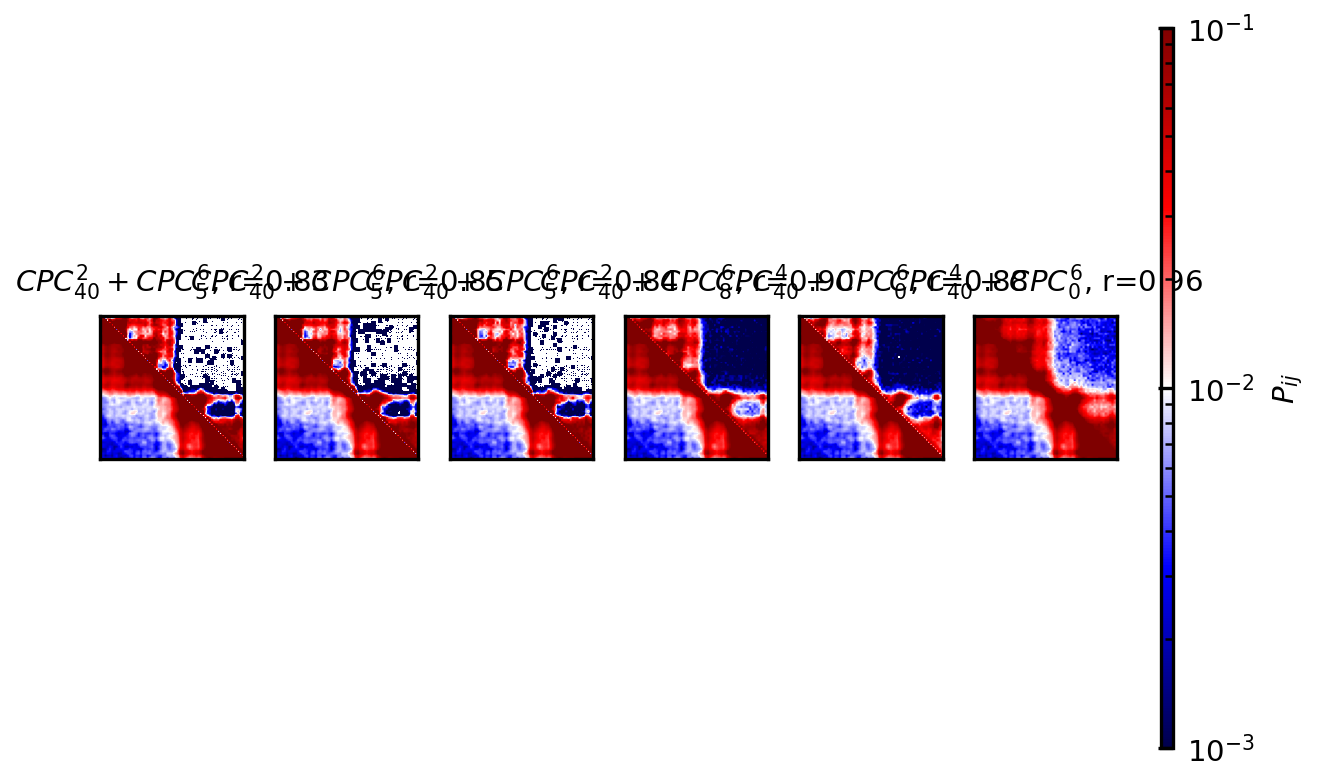

In [11]:

# %% [markdown]
# ## 3. 绘图：接触概率热图 (Contact Maps)

# %%
fig1 = plot_heatmaps_row(
    sim_data, groups_to_process, group_labels, 
    metric_key='contact_pro', 
    hic_ref=hic_matrix,
    cmap='seismic'
)
# fig1.savefig(os.path.join(OUTPUT_DIR, 'Figure_ContactMaps.pdf'))
plt.show()


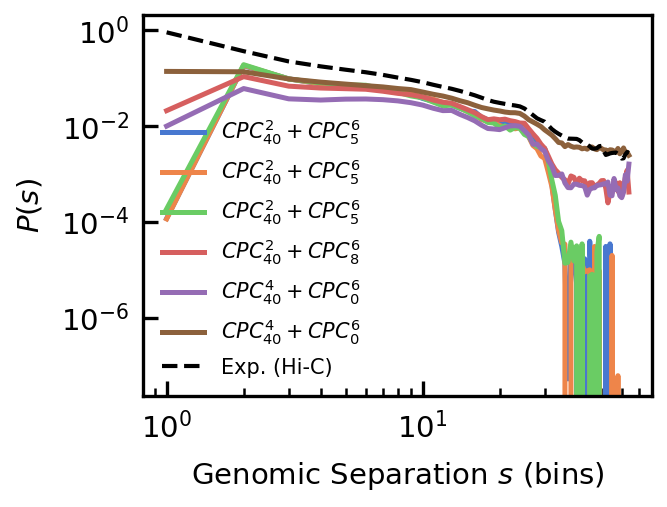

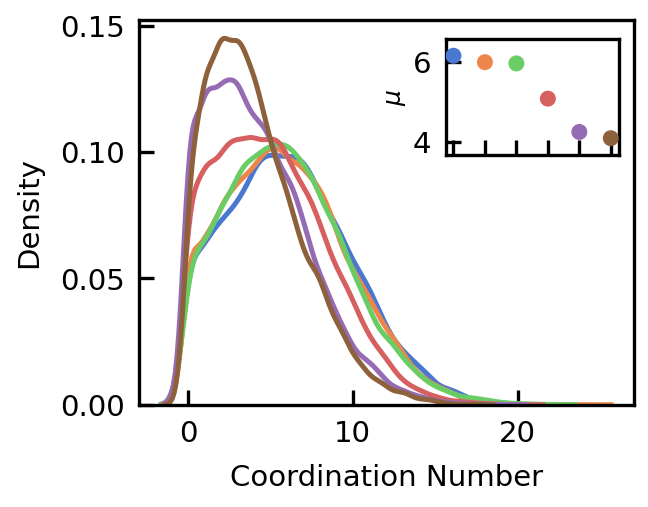

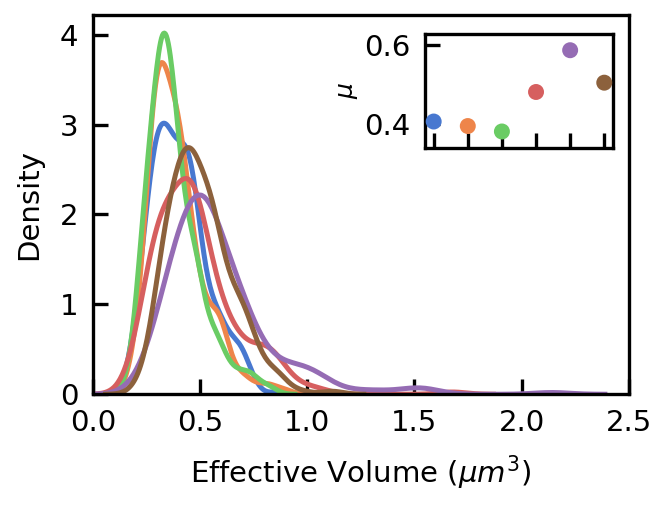

/hpc2hdd/home/jtang163/work/MC-PEPMEM/PolymermcCPCMEM/PLOT/chrom_core.py:162: RuntimeWarning: Mean of empty slice
  score[i] = np.nanmean(region)


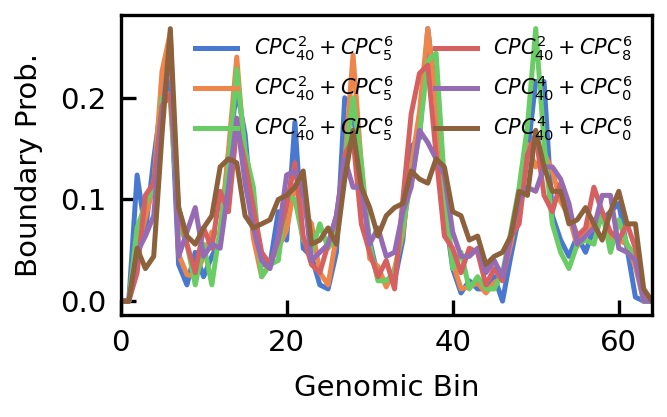

In [12]:

# %% [markdown]
# ## 4. 绘图：P(s) 曲线

# %%
fig2 = cc.plot_ps_curves(sim_data, hic_matrix, groups_to_process, group_colors, group_labels)
# fig2.savefig(os.path.join(OUTPUT_DIR, 'Figure_Ps.pdf'))
plt.show()

# %% [markdown]
# ## 5. 绘图：配位数 (Coordination Number)

# %%
cn_vals = {}
cn_means = {}
for grp, d in sim_data.items():
    vals = cc.compute_coordination_numbers(d['dist_matrices'], r_c=1.6, mu=4.0)
    cn_vals[grp] = vals
    cn_means[grp] = np.mean(vals)

fig3 = cc.plot_kde_with_inset(
    cn_vals, cn_means, groups_to_process, group_colors,
    x_label='Coordination Number'
)
# fig3.savefig(os.path.join(OUTPUT_DIR, 'Figure_CoordNum.pdf'))
plt.show()

# %% [markdown]
# ## 6. 绘图：有效体积 (Volume)

# %%
vol_factor = (0.133)**3
vol_vals = {}
vol_means = {}

for grp, d in sim_data.items():
    v = np.array(d['polymer_volumes'])
    v = v[v > 0] # Filter failures
    if len(v) > 0:
        vol_vals[grp] = v
        vol_means[grp] = np.mean(v) * vol_factor

fig4 = cc.plot_kde_with_inset(
    vol_vals, vol_means, groups_to_process, group_colors,
    x_label=r'Effective Volume ($\mu m^3$)',
    unit_scale=vol_factor,
    x_lim=(0, 2.5) # 可选：根据数据手动微调
)
# fig4.savefig(os.path.join(OUTPUT_DIR, 'Figure_Volume.pdf'))
plt.show()

# %% [markdown]
# ## 7. 绘图：TAD 边界概率

# %%
fig5, ax = plt.subplots(figsize=(cc.PRL_PAGE_WIDTH/3, 1.5))

# 绘制模拟
for grp in groups_to_process:
    if grp in sim_data:
        probs = cc.compute_boundary_prob(sim_data[grp]['dist_matrices'], cc.N_BEADS_GLOBAL)
        ax.plot(probs, label=group_labels[grp], color=group_colors[grp])

# 绘制实验 (如果需要，需从Exp Dist File计算，这里仅留框架)
# ax.plot(exp_probs, 'k--', label='Exp')

ax.set_xlabel("Genomic Bin")
ax.set_ylabel("Boundary Prob.")
ax.set_xlim(0, cc.N_BEADS_GLOBAL-1)
ax.legend(frameon=False, fontsize=5, ncol=2)

plt.tight_layout()
# fig5.savefig(os.path.join(OUTPUT_DIR, 'Figure_BoundaryProb.pdf'))
plt.show()

In [6]:
# CONTACT MAP (Restored Probability Calculation)
from scipy.spatial.distance import cdist, pdist, squareform
from itertools import combinations

# ===================================================================
# 1. 参数定义区
# ===================================================================
# --- 自动解析参数 ---
group_name_to_analyze = 'CN2_40_CN4_10' # <-- 在这里修改为您想分析的组名

if group_name_to_analyze in sim_data:
    # 使用更通用的正则表达式来匹配混合类型
    tf_matches = re.findall(r'CN(\d+)_(\d+)', group_name_to_analyze)
    if len(tf_matches) == 2:
        conn1, count1 = map(int, tf_matches[0])
        conn2, count2 = map(int, tf_matches[1])
        # conn2, count2 = 6, 20
        
        type1_name, type2_name = f'CN{conn1}', f'CN{conn2}'
    else: # 处理单类型的情况作为备用
        conn1, count1 = map(int, tf_matches[0])
        conn2, count2 = 0, 0
        type1_name, type2_name = f'CN{conn1}', f'N/A'
    
    print(f"--- 分析目标: {group_name_to_analyze} ---")
    print(f"粒子1: {type1_name}, 数量: {count1}")
    print(f"粒子2: {type2_name}, 数量: {count2}")

    # --- 物理参数 (确保与模拟一致) ---
    k_c = 14.0
    r0 = 1.2
    Pcutoff_ik = 1.5


    # --- 获取数据 ---
    sim_results = sim_data[group_name_to_analyze]

    # ===================================================================
    # 2. 核心计算逻辑 (恢复为生成接触概率图)
    # ===================================================================

    # 初始化累加矩阵
    total_contact_map_type1 = np.zeros((N_BEADS_GLOBAL, N_BEADS_GLOBAL))
    total_contact_map_type2 = np.zeros((N_BEADS_GLOBAL, N_BEADS_GLOBAL))
    num_frames = len(sim_results["polymer_coords"])

    print(f"\nProcessing {num_frames} frames to generate contact maps...")
    for frame_coords in sim_results["polymer_coords"]:
        # print(len(frame_coords))
        polymer_coords = frame_coords[0:N_BEADS_GLOBAL]
        tf_coords = frame_coords[N_BEADS_GLOBAL:]

        # 为每一帧创建对数项矩阵
        log_term_matrix_type1 = np.zeros((N_BEADS_GLOBAL, N_BEADS_GLOBAL))
        log_term_matrix_type2 = np.zeros((N_BEADS_GLOBAL, N_BEADS_GLOBAL))
        
        # --- 处理第一种粒子 ---
        if count1 > 0:
            type1_coords = tf_coords[:count1]
            dist_mat_poly = cdist(type1_coords, polymer_coords)

            for i_tf in range(count1):
                dists = dist_mat_poly[i_tf, :]
                neighbor_indices = np.where(dists < Pcutoff_ik)[0]
                if len(neighbor_indices) < 2: continue
                
                closest_neighbors_idx = neighbor_indices[np.argsort(dists[neighbor_indices])[:conn1]]
                
                for i, j in combinations(closest_neighbors_idx, 2):
                    dist1, dist2 = dists[i], dists[j]
                    P_ik = 0.5 * (1.0 - np.tanh(k_c * (dist1 - r0)))
                    P_jk = 0.5 * (1.0 - np.tanh(k_c * (dist2 - r0)))
                    term = np.log(max(np.finfo(float).eps, 1.0 - P_ik * P_jk))
                    log_term_matrix_type1[min(i, j), max(i, j)] += term

        # --- 处理第二种粒子 ---
        if count2 > 0:
            type2_coords = tf_coords[count1:]
            dist_mat_poly = cdist(type2_coords, polymer_coords)
            for i_tf in range(count2):
                dists = dist_mat_poly[i_tf, :]
                neighbor_indices = np.where(dists < Pcutoff_ik)[0]
                if len(neighbor_indices) < 2: continue

                closest_neighbors_idx = neighbor_indices[np.argsort(dists[neighbor_indices])[:conn2]]
                
                for i, j in combinations(closest_neighbors_idx, 2):
                    dist1, dist2 = dists[i], dists[j]
                    P_ik = 0.5 * (1.0 - np.tanh(k_c * (dist1 - r0)))
                    P_jk = 0.5 * (1.0 - np.tanh(k_c * (dist2 - r0)))
                    term = np.log(max(np.finfo(float).eps, 1.0 - P_ik * P_jk))
                    log_term_matrix_type2[min(i, j), max(i, j)] += term

        # 将对数项转换回概率并累加到总矩阵
        contact_map_frame_type1 = 1.0 - np.exp(log_term_matrix_type1)
        total_contact_map_type1 += contact_map_frame_type1
        
        contact_map_frame_type2 = 1.0 - np.exp(log_term_matrix_type2)
        total_contact_map_type2 += contact_map_frame_type2

    # 计算系综平均
    avg_contact_map_type1 = total_contact_map_type1 / num_frames if num_frames > 0 else total_contact_map_type1
    avg_contact_map_type2 = total_contact_map_type2 / num_frames if num_frames > 0 else total_contact_map_type2
    
    # 使最终的平均矩阵对称
    avg_contact_map_type1 = avg_contact_map_type1 + avg_contact_map_type1.T
    avg_contact_map_type2 = avg_contact_map_type2 + avg_contact_map_type2.T

    print("\nCalculation complete.")


NameError: name 'avg_contact_map_type1' is not defined

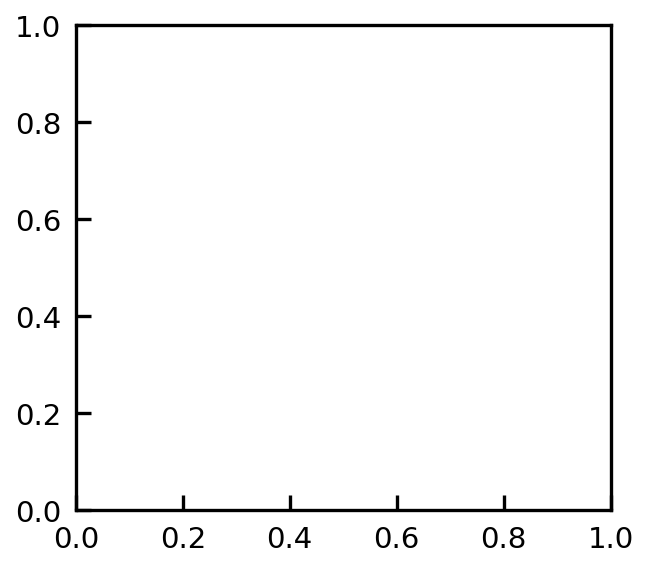

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# ===================================================================
# 绘图 1: 接触概率/频率热图 (Split Triangle Style)
# ===================================================================

# 1. 尺寸设置：2.3 x 2.1 inch (接近正方形，符合单栏布局)
fig, ax = plt.subplots(figsize=(2.3, 2.1))

# 2. 数据准备：上三角为正(Type1)，下三角为负(Type2)
# 使用 seismic_r 色谱：正值=蓝色，负值=红色，0=白色
plot_matrix = np.triu(avg_contact_map_type1) - np.tril(avg_contact_map_type2, k=-1)

# 确定颜色范围，保证0在中间
max_val = max(np.max(avg_contact_map_type1), np.max(avg_contact_map_type2))

# 3. 绘制热图
im = ax.imshow(plot_matrix, cmap="seismic_r", vmin=-max_val, vmax=max_val, origin='upper')

# 4. 样式去除：无刻度
ax.set_xticks([])
ax.set_yticks([])
ax.tick_params(axis='both', which='both', length=0)

# 5. 添加内部标签 (右上蓝色，左下红色)
label1 = f"$CPC^{{{conn1}}}_{{{count1}}}$"
label2 = f"$CPC^{{{conn2}}}_{{{count2}}}$"

# 右上 (Type 1 - 蓝色系)
ax.text(0.95, 0.95, label1, transform=ax.transAxes, 
        color="#2E3E93", fontsize=8, fontweight='bold', ha='right', va='top')
# 左下 (Type 2 - 红色系)
ax.text(0.05, 0.05, label2, transform=ax.transAxes, 
        color="#961423", fontsize=8, fontweight='bold', ha='left', va='bottom')

# 6. 边框加粗
for spine in ax.spines.values():
    spine.set_linewidth(0.8)

# 7. Colorbar 设置 (去除负号)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('$P_{ij}$', fontsize=7, labelpad=2)
cbar.ax.tick_params(labelsize=6, size=2, width=0.6)
cbar.outline.set_linewidth(0.6)

# 关键：格式化刻度，显示绝对值
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.2f}"))

plt.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)
# plt.savefig(os.path.join(FIG_OUTPUT_DIR, "FIG_Contact_Map_Split.pdf"), bbox_inches='tight')
plt.show()

In [ ]:

# 2. 准备行和的数据 (代表“总接触概率”)
contact_map_type1_row_sums = np.sum(avg_contact_map_type1, axis=1)
contact_map_type2_row_sums = np.sum(avg_contact_map_type2, axis=1)

# ===================================================================
# 绘图 2: 接触行和曲线 (含 Hi-C Sum 双轴对比)
# ===================================================================

# 0. 准备 Hi-C 数据 (假设 hic_matrix 已存在)
hic_row_sums = np.sum(hic_matrix, axis=1)

# 1. 尺寸设置
fig2, ax2 = plt.subplots(figsize=(2.3, 1.5))

# 2. X轴索引
bead_indices = np.arange(len(contact_map_type1_row_sums))

# --- 左轴：模拟数据 (Simulation) ---
# CAP1 (Blue #3E51C4), CAP2 (Red #BB182B)
l1, = ax2.plot(bead_indices, contact_map_type1_row_sums, 
               color='#3E51C4', linestyle='-', linewidth=1.2, label=f'$CPC^{{{conn1}}}$')
l2, = ax2.plot(bead_indices, contact_map_type2_row_sums, 
               color='#BB182B', linestyle='-', linewidth=1.2, label=f'$CPC^{{{conn2}}}$')

ax2.set_ylabel(r'$\sum_{j} P_{ij}$', fontsize=6, labelpad=1)
ax2.tick_params(axis='y', labelsize=6, direction='in', length=2)
ax2.set_xlim(-0.5, len(bead_indices) - 0.5)

# --- 右轴：实验数据 (Hi-C) ---
ax2_twin = ax2.twinx()
# Hi-C (Black -.)
l3, = ax2_twin.plot(bead_indices, hic_row_sums, color='black', 
                    linestyle='-.', linewidth=0.8, label='Hi-C Sum')

ax2_twin.set_ylabel('Hi-C Row Sum', color='black', fontsize=7, labelpad=1)
ax2_twin.tick_params(axis='y', labelcolor='black', labelsize=6, direction='in', length=2)

# 3. X轴刻度映射 (28MB, 29MB, 30MB)
# ax2.set_xticks([4, 33, 60])
# ax2.set_xticklabels(["28MB", "29MB", "30MB"])
ax2.tick_params(axis='x', labelsize=6, direction='in', length=0)

# 4. 合并图例 (顶部居中, 3列)
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.25), 
           ncol=3, frameon=False, fontsize=6, handlelength=1.2, columnspacing=1.0)

# 5. 边框加粗
for ax in [ax2, ax2_twin]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

plt.subplots_adjust(top=0.8, bottom=0.2, left=0.15, right=0.85)
# plt.savefig(os.path.join(FIG_OUTPUT_DIR, "FIG_Contact_RowSum_DualAxis.pdf"), bbox_inches='tight')
plt.show()